# Naive Bayes Spam Classifier

# 1 - Imports and Configuration

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string
%matplotlib inline

# 2 - Data Loading and Exploration

In [ ]:
# The spam.csv file contains 5572 SMS labeled 'ham' or 'spam'
data = pd.read_csv('spam.csv', sep='\t', encoding = 'latin1')
data

,class,message
0,ham,Go until jurong point crazy.. Available only ...
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,Nah I don't think he goes to usf he lives aro...
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,Pity * was in mood for that. So...any other s...
5570,ham,The guy did some bitching but I acted like i'd...


# 3 - Data Preprocessing

(array([4.98e+02, 1.68e+03, 9.13e+02, 5.84e+02, 3.84e+02, 4.14e+02,
        7.90e+02, 1.72e+02, 3.60e+01, 1.40e+01, 2.00e+01, 7.00e+00,
        1.70e+01, 5.00e+00, 1.40e+01, 1.00e+00, 6.00e+00, 1.00e+00,
        2.00e+00, 5.00e+00, 2.00e+00, 1.00e+00, 0.00e+00, 0.00e+00,
        0.00e+00, 2.00e+00, 1.00e+00, 1.00e+00, 0.00e+00, 0.00e+00,
        0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 1.00e+00, 0.00e+00,
        0.00e+00, 0.00e+00, 0.00e+00, 1.00e+00]),
 array([  2. ,  24.7,  47.4,  70.1,  92.8, 115.5, 138.2, 160.9, 183.6,
        206.3, 229. , 251.7, 274.4, 297.1, 319.8, 342.5, 365.2, 387.9,
        410.6, 433.3, 456. , 478.7, 501.4, 524.1, 546.8, 569.5, 592.2,
        614.9, 637.6, 660.3, 683. , 705.7, 728.4, 751.1, 773.8, 796.5,
        819.2, 841.9, 864.6, 887.3, 910. ]),
 <BarContainer object of 40 artists>)

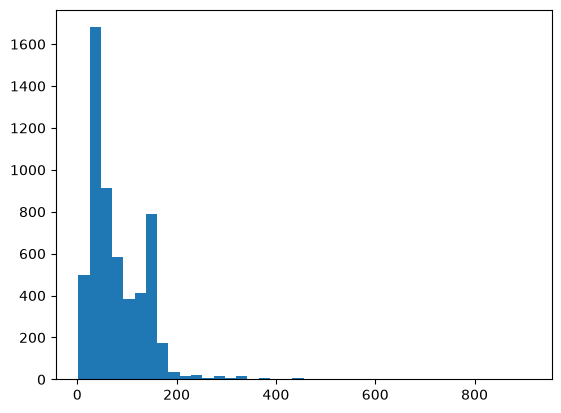

In [90]:
# Length can be a spam indicator (spams are often longer)
data['length'] = [len(data['message'][i]) for i in range(len(data))]
plt.hist(data['length'],bins = 40)

In [14]:
(len(data[data['class'] == 'spam']),len(data[data['class'] == 'ham']))

(747, 4825)

In [91]:
# Stop words: common words that don't carry information
stop_words = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

In [92]:
def remove_punctuation(mess):
    """
    Replace punctuation with spaces.
    Useful for splitting words that are concatenated with punctuation.
    """
    res = ''
    for c in mess:
        if c not in string.punctuation:
            res += c
        else:
            res += ' '
    return res


In [93]:
def string_to_list(mess):
    """
    Convert a message to a list of meaningful words.
    Steps: 1) Remove punctuation  2) Split  3) Remove stop words
    """
    res = remove_punctuation(mess).split()
    return [i for i in res if i.lower() not in stop_words]

In [94]:
# Apply preprocessing
data["list_words"] = data["message"].apply(string_to_list)
data

,class,message,length,list_words
0,ham,Go until jurong point crazy.. Available only ...,111,"[Go, jurong, point, crazy, Available, bugis, n..."
1,ham,Ok lar... Joking wif u oni...,29,"[Ok, lar, Joking, wif, u, oni]"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,"[Free, entry, 2, wkly, comp, win, FA, Cup, fin..."
3,ham,U dun say so early hor... U c already then say...,49,"[U, dun, say, early, hor, U, c, already, say]"
4,ham,Nah I don't think he goes to usf he lives aro...,61,"[Nah, think, goes, usf, lives, around, though]"
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,"[2nd, time, tried, 2, contact, u, U, å£750, Po..."
5568,ham,Will Ì_ b going to esplanade fr home?,37,"[Ì, b, going, esplanade, fr, home]"
5569,ham,Pity * was in mood for that. So...any other s...,57,"[Pity, mood, suggestions]"
5570,ham,The guy did some bitching but I acted like i'd...,125,"[guy, bitching, acted, like, interested, buyin..."


# 4 - Indexing and Vectorization

In [101]:
def indexation(data):
    """
    Create a dictionary mapping each unique word to a numeric index.
    Args:
        data: DataFrame with 'words_list' column
    Returns:
        dict: {word: index}
    """    
    d = dict()
    compt = 0
    tab = data['list_words']
    for i in range(len(data)):
        for j in data["list_words"][i]:
            if j not in d:
                d[j] = compt
                compt+=1
    return d
indexation(data)

{'Go': 0,
 'jurong': 1,
 'point': 2,
 'crazy': 3,
 'Available': 4,
 'bugis': 5,
 'n': 6,
 'great': 7,
 'world': 8,
 'la': 9,
 'e': 10,
 'buffet': 11,
 'Cine': 12,
 'got': 13,
 'amore': 14,
 'wat': 15,
 'Ok': 16,
 'lar': 17,
 'Joking': 18,
 'wif': 19,
 'u': 20,
 'oni': 21,
 'Free': 22,
 'entry': 23,
 '2': 24,
 'wkly': 25,
 'comp': 26,
 'win': 27,
 'FA': 28,
 'Cup': 29,
 'final': 30,
 'tkts': 31,
 '21st': 32,
 'May': 33,
 '2005': 34,
 'Text': 35,
 '87121': 36,
 'receive': 37,
 'question': 38,
 'std': 39,
 'txt': 40,
 'rate': 41,
 'C': 42,
 'apply': 43,
 '08452810075over18': 44,
 'U': 45,
 'dun': 46,
 'say': 47,
 'early': 48,
 'hor': 49,
 'c': 50,
 'already': 51,
 'Nah': 52,
 'think': 53,
 'goes': 54,
 'usf': 55,
 'lives': 56,
 'around': 57,
 'though': 58,
 'FreeMsg': 59,
 'Hey': 60,
 'darling': 61,
 '3': 62,
 'week': 63,
 'word': 64,
 'back': 65,
 'like': 66,
 'fun': 67,
 'still': 68,
 'Tb': 69,
 'ok': 70,
 'XxX': 71,
 'chgs': 72,
 'send': 73,
 'å£1': 74,
 '50': 75,
 'rcv': 76,
 'Even': 

In [102]:
def presence(d):
    """
    Build the binary presence matrix.
    Row = message, Column = word, Value = 1 if present, 0 otherwise.
    
    Args:
        data: DataFrame with 'words_list' column
        vocab: Indexing dictionary
    Returns:
        np.array: Presence matrix (n_messages × n_words)
    """
    tab = d["list_words"]
    dict = indexation(d)
    res = np.zeros((len(d),len(dict)))
    for i in range(len(d)):
        for word in tab[i]:
            res[i][dict[word]] = 1
    return res
pres = presence(data)

# 5 - Naive Bayes Model

<div>
We adopt the naive Bayesian approach, which consists of approximating the probability of observing a message X given its class Y by the product of the probabilities of occurrence of each word composing it, given its class. Denoting P(word | Y) as the probability that the word <code>word</code> appears in a message, given that this message belongs to class Y, we thus set:

$$ p(X = {\bf x} | Y) = \prod_{word \in vocabulary} p(word | Y)^{x_{word}} \left(1 - p(word | Y)\right)^{1 - x_{word}} $$

This is a <em>bag-of-words</em> model in which word order is not taken into account and for which we make the assumption of conditional independence of word occurrences.
</div>


In [103]:
# P(Y) = proportion of classes in the data
Probham = len(data[data['class']  == 'ham'])/len(data)
ProbSpam = len(data[data['class']  == 'spam'])/len(data)

# P(word | Y) = frequency of word in messages of class Y
ProbwHam = np.mean(pres[data['class']=='ham'],axis = 0)
ProbwSpam = np.mean(pres[data['class']=='spam'],axis = 0)

In [45]:
PhamX = Probham*np.prod(((ProbwHam)**pres)*((1-ProbwHam)**(1-pres)),axis = 1)
PspamX = Probspam*np.prod(((ProbwSpam)**pres)*((1-ProbwSpam)**(1-pres)),axis = 1)

In [107]:
pred = (Probham*np.prod(ProbwHam**pres*(1-ProbwHam)**(1-pres),axis = 1))>(Probspam*np.prod(ProbwSpam**pres*(1-ProbwSpam)**(1-pres),axis=1))
norm_vect = np.array((data['class'] == "ham")+0)

In [108]:
def confusion_matrix(prediction,normal):
    """
    Calculate confusion matrix.
    Format: [[TN, FP], [FN, TP]]
    """
    m = np.zeros((2,2))
    for k in range(len(prediction)):
        i = prediction[k]+0
        j = normal[k]+0
        m[j][i] = m[j][i] + 1
    return m

In [41]:
confusion_matrix(pred,norm_vect)

array([[7.460e+02, 1.000e+00],
       [0.000e+00, 4.825e+03]])

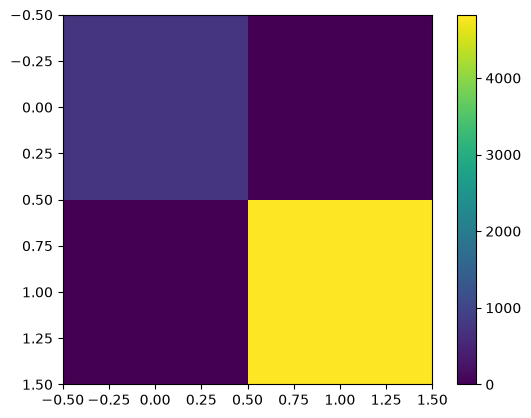

In [42]:
_ = plt.imshow(confusion_matrix(pred, norm_vect), interpolation='none')
_ = plt.colorbar()

# 6 - Proper Evaluation(Train/Test Split)

In [111]:
def train_model(data_train):
    """
    Train the Naive Bayes model on training data.
    
    Args:
        train_data: Training DataFrame
    Returns:
        tuple: (vocab, prob_ham, prob_spam, prob_word_given_ham, prob_word_given_spam)
    """
    vocab = dict()
    for word in data_train['list_words']:
        for w in word:
            if w not in vocab:
                vocab[w] = len(vocab)
    pres_train = np.zeros((len(data_train),len(vocab)))
    for i in range(len(data_train)):
        for word in data_train['list_words'][i]:
            pres_train[i][vocab[word]] = 1
    Pham = len(data_train[data_train['class'] == 'ham']) / len(data_train)
    Pspam = len(data_train[data_train['class'] == 'spam']) / len(data_train)
    alpha = 1.0
    ham_indices = data_train['class'] == 'ham'
    spam_indices = data_train['class'] == 'spam'
    PmHam = (np.sum(pres_train[ham_indices], axis=0) + alpha) / (np.sum(ham_indices) + alpha * len(vocab))
    PmSpam = (np.sum(pres_train[spam_indices], axis=0) + alpha) / (np.sum(spam_indices) + alpha * len(vocab))
    
    return vocab, PmHam, PmSpam, Pham, Pspam


In [112]:
def classification(message, vocab, PmHam, PmSpam, Pham, Pspam):
    """
    Classify a new message.
    
    Args:
        message: str, the message to classify
        vocab: dict, learned vocabulary
        prob_ham, prob_spam: prior probabilities
        prob_word_given_ham, prob_word_given_spam: conditional probabilities
    Returns:
        tuple: (class, score_ham, score_spam)
    """
    word_msg = string_to_list(message)
    X = np.zeros(len(vocab))
    for word in word_msg:
        if word in vocab:
            X[vocab[word]] = 1
    log_PhamX = np.log(Pham) + np.sum(X * np.log(PmHam) + (1 - X) * np.log(1 - PmHam))
    log_PspamX = np.log(Pspam) + np.sum(X * np.log(PmSpam) + (1 - X) * np.log(1 - PmSpam))

    if log_PhamX > log_PspamX:
        return 'ham',np.exp(log_PhamX),np.exp(log_PspamX)
    else:
        return 'spam',np.exp(log_PhamX),np.exp(log_PspamX)
    

Splitting the Data

In [113]:
np.random.seed(42)  # Pour reproductibilité
indices = np.random.permutation(len(data))
train_size = int(0.8 * len(data))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

Data_train = data.iloc[train_indices].copy().reset_index(drop=True)
Data_test = data.iloc[test_indices].copy().reset_index(drop=True)
Data_train
vocab, PmHam, PmSpam, Pham, Pspam = train_model(Data_train)

# 7 - Visualizations

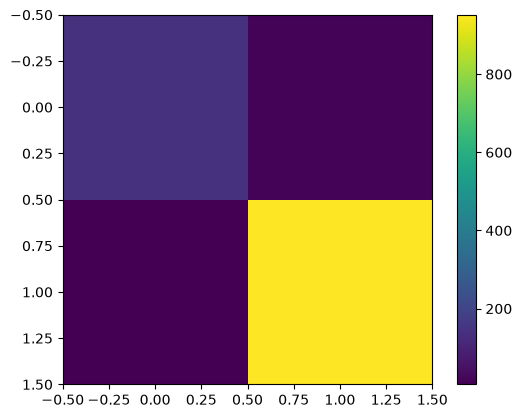

In [114]:
vocab, PmHam, PmSpam, Pham, Pspam = train_model(Data_train)
predictions = []
prob_ham = []
prob_spam = []

for _, row in Data_test.iterrows():
    pred, ph, ps = classification(row['message'], vocab, PmHam, PmSpam, Pham, Pspam)
    predictions.append(pred)
    prob_ham.append(ph)
    prob_spam.append(ps)

Data_test['prediction'] = predictions
Data_test['prob_ham'] = prob_ham
Data_test['prob_spam'] = prob_spam

true = (Data_test['class'] == 'ham').astype(int)
pred = (Data_test['prediction'] == 'ham').astype(int)

confusion = np.zeros((2, 2))
for p, v in zip(pred, true):
    confusion[v, p] += 1
_ = plt.imshow(confusion, interpolation='none')
_ = plt.colorbar()

# Error analysis


In [115]:
accuracy = (confusion[0,0] + confusion[1,1]) / len(Data_test)

precision_ham = confusion[0,0] / (confusion[0,0] + confusion[1,0]) if (confusion[0,0] + confusion[1,0]) > 0 else 0
recall_ham = confusion[0,0] / (confusion[0,0] + confusion[0,1]) if (confusion[0,0] + confusion[0,1]) > 0 else 0
f1_ham = 2 * precision_ham * recall_ham / (precision_ham + recall_ham) if (precision_ham + recall_ham) > 0 else 0

precision_spam = confusion[1,1] / (confusion[1,1] + confusion[0,1]) if (confusion[1,1] + confusion[0,1]) > 0 else 0
recall_spam = confusion[1,1] / (confusion[1,1] + confusion[1,0]) if (confusion[1,1] + confusion[1,0]) > 0 else 0
f1_spam = 2 * precision_spam * recall_spam / (precision_spam + recall_spam) if (precision_spam + recall_spam) > 0 else 0

In [117]:
print("\nPerformance:")
print("  Accuracy: ",accuracy * 100)
print("  F1-score (ham): ",f1_ham * 100)
print("  F1-score (spam): ",f1_spam * 100)

# 6. Error analysis
false_positives = Data_test[(Data_test['prediction'] == 'spam') & (Data_test['class'] == 'ham')]
false_negatives = Data_test[(Data_test['prediction'] == 'ham') & (Data_test['class'] == 'spam')]

print("\nError Analysis:")
print("  False Positives (pred spam, true ham): " + str(len(false_positives)))
print("  False Negatives (pred ham, true spam): " + str(len(false_negatives)))

if len(false_positives) > 0:
    print("\n  Example false positive:")
    print(false_positives.iloc[0]['message'][:100])

if len(false_negatives) > 0:
    print("\n  Example false negative:")
    print(false_negatives.iloc[0]['message'][:100])


Performance:
  Accuracy:  98.11659192825111
  F1-score (ham):  93.11475409836065
  F1-score (spam):  98.9090909090909

Error Analysis:
  False Positives (pred spam, true ham): 6
  False Negatives (pred ham, true spam): 15

  Example false positive:
ALRITE SAM ITS NIC JUST CHECKIN THAT THIS IS UR NUMBER-SO IS IT?T.B*

  Example false negative:
RCT' THNQ Adrian for U text. Rgds Vatian
